# Bobs Word Embeddings

Dieses Programm wandelt Wörter in Vektoren (Embeddings) um und visualisiert diese im 2D-Raum.

**Pipeline:**
1. Wörter definieren
2. Embeddings berechnen 
3. Dimension reduzieren (Principal Component Analysis)
4. Visualisierung als 2D-Vektoren
5. Visualisierung der Ähnllichkeiten mittels Heatmap

**Voraussetzungen:**
- Ollama läuft lokal (http://localhost:11434)
- Download-Link: https://ollama.com/download/windows
- hier mit folgendem Embedding-Modell: 
    -  all-minilm

**Wichtig:**
- Die tatsächlichen Embeddings haben viele Dimensionen (hier 384).
- Für die Visualisierung als Vektoren reduzieren wir sie auf 2 Dimensionen mittels Principal Componet Analysis (PCA).


## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from langchain_ollama import OllamaEmbeddings

## Konfiguration
Hier werden zentrale Parameter definiert:
- wo Ollama erreichbar ist
- welches Embedding-Modell verwendet wird

In [2]:
OLLAMA_BASE_URL = "http://localhost:11434"
EMBEDDING_MODEL = "all-minilm"

## 1. Wörter definieren
Diese Wörter werden später in Vektoren umgewandelt.

In [3]:
hobbies = ["Natur", "Sport", "Wandern", "Klettern", "Yoga", "Meditation", "Kochen", "Backen"]


In [5]:
properties = ["spontan", "neugierig", "unternehmungslustig", "aktiv",
                   "ausgeglichen", "zurückgezogen", "detailorientiert", "entspannt"]

In [6]:
words = hobbies # hier wird festgelegt, welche Wortliste später verwendet wird

## 2. Embeddings berechnen
Wandelt die gegebenen Wörter in numerische Vektoren (Embeddings) um. 

Diese Vektoren repräsentieren die Bedeutung der Wörter und ermöglichen semantische Suche.

In [7]:
embeddings = OllamaEmbeddings(
    model=EMBEDDING_MODEL,
    base_url=OLLAMA_BASE_URL
)

# Wörter → Vektoren
embeddings = embeddings.embed_documents(words)

### Dimension der Vektoren:

In [8]:
len(embeddings[0])  

384

## 3. Dimension reduzieren (PCA)

Da die Embeddings viele Dimensionen haben,
reduzieren wir sie auf 2 Dimensionen für die Visualisierung.

PCA (Principal Component Analysis):
- findet die wichtigsten Richtungen im Datenraum
- projiziert die Daten auf diese Achsen

In [9]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

### Dimension der Vektoren nach PCA:

In [10]:
len(embeddings_2d[0])

2

## 4. Visualisierung als 2D-Vektoren

Diese Funktion stellt die durch die PCA erhaltenen 2D-Vektoren grafisch dar. 

In [11]:
def show_embeddings(words, embeddings_2d):
    plt.figure(figsize=(7, 5))

    # Define colors for each word
    colors = ["#A371F3", "#CC0000", "magenta", "#360B7B", "#0BD5DF", "green", "gold", "orange"]

    # Plot vectors from origin to each point
    for i, word in enumerate(words):
        x, y = embeddings_2d[i]
        color = colors[i % len(colors)]
        plt.arrow( 0, 0, x, y, head_width=0.02, head_length=0.03, fc=color, ec=color, alpha=0.7, length_includes_head=True)

        # Add dot at the end of the vector with PCA coordinates in legend
        label = f"{word}"# ({x:.2f}, {y:.2f})"
        plt.scatter(x, y, color=color, s=100, marker="o", label=label)

    plt.title("2D-Vektordarstellung der Word Embeddings (PCA)\n", fontsize=13)
    plt.xlabel("PCA Komponente 1", fontsize=12)
    plt.ylabel("PCA Komponente 2", fontsize=12)
    
    #plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')# loc='lower right')
    plt.axis("equal")  # Equal aspect ratio to preserve vector angles
    plt.tight_layout()
    plt.show()

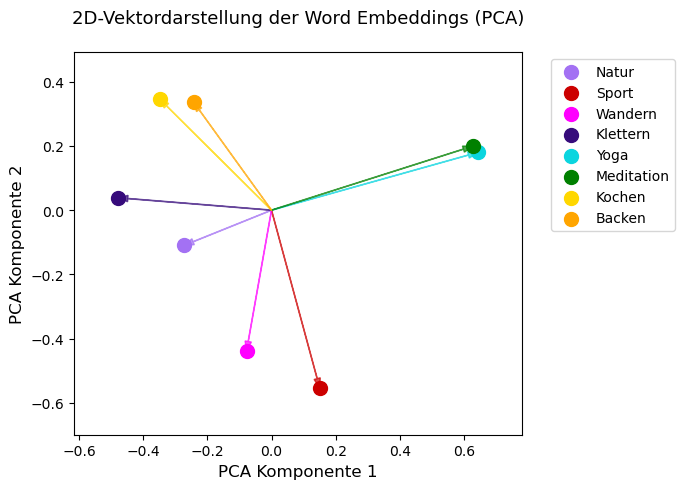

In [12]:
show_embeddings(words, embeddings_2d)

## 5. Visualisierung der Ähnlichkeiten

##### Funktion zum Plotten der Heatmaps

In [13]:
def plot_heatmap(distance_matrix, words, title):

    """
    Visualisiert eine Distanzmatrix als Heatmap.

    Parameter:
    - distance_matrix: nxn Matrix mit Distanzen
    - words: Labels für Achsen
    - title: Titel der Darstellung
    """
    
    distance_matrix = np.array(distance_matrix)

    plt.figure(figsize=(8, 6))

    # Farbskala
    im = plt.imshow(distance_matrix, cmap="coolwarm", vmin=0, vmax=np.max(distance_matrix))
    plt.colorbar(im)
    
    # Titel
    plt.title(title + "\nHeatmap", fontsize=10)
    
    # Achsenbeschriftung
    plt.xticks(range(len(words)), words,fontsize=9, rotation=45)
    plt.yticks(range(len(words)), words, fontsize=9)

    # Werte in Zellen anzeigen
    for i in range(distance_matrix.shape[0]):
        for j in range(distance_matrix.shape[1]):
            plt.text(j, i, f"{distance_matrix[i, j]:.2f}",
                     ha="center", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

### Ähnlichkeit von Vektoren I: Euklidische Distanz

In [14]:
from scipy.spatial.distance import euclidean

##### Berechnung der Distanzmatrix

In [15]:
def calculate_pairwise_euclidean_matrix(vectors):

    """
    Berechnet alle paarweisen euklidischen Distanzen.
    """
    
    n = len(vectors)
    
    # leere nxn Matrix
    distances = np.zeros((n, n))

    # Berechnen der Distanzen
    for i in range(n):
        for j in range(n):
            distances[i, j] = euclidean(np.array(vectors[i]), np.array(vectors[j]))
    
    return distances

In [16]:
eucl_dist_matrix = calculate_pairwise_euclidean_matrix(embeddings)

##### Visualisierung als Heatmap

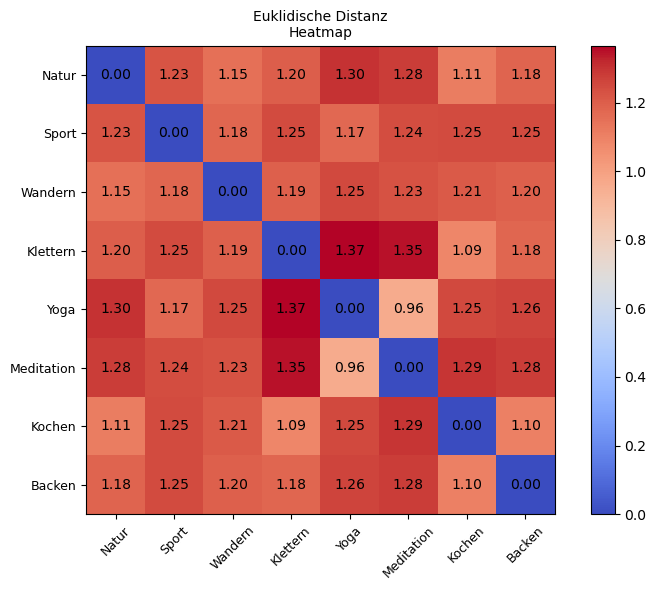

In [17]:
plot_heatmap(eucl_dist_matrix, words, "Euklidische Distanz")

### Ähnlichkeit von Vektoren II: Kosinus-Distanz

In [18]:
from scipy.spatial.distance import cosine

##### Berechnung der Distanzmatrix

In [19]:
def calculate_pairwise_cosine_matrix(vectors):

    """
    Berechnet alle paarweisen Kosinus-Distanzen.
    """
    
    n = len(vectors)
    
    # leere nxn Matrix
    distances = np.zeros((n, n))

    # Berechnen der Distanzen
    for i in range(n):
        for j in range(n):
            distances[i, j] = cosine(np.array(vectors[i]), np.array(vectors[j]))
    
    return distances

In [20]:
cosine_matrix = calculate_pairwise_cosine_matrix(embeddings)

##### Visualisierung als Heatmap

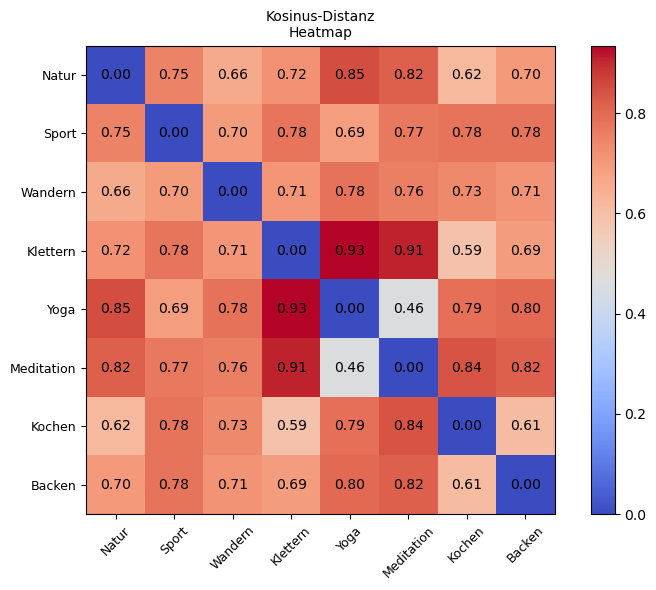

In [21]:
plot_heatmap(cosine_matrix, words, "Kosinus-Distanz")